## Applied K-Means clustering

In this section we will apply K-Means clustering to a famous data set that is often used in introductory Machine Learning texts. The digits data set is a collection of 8x8 pixel images of handwritten digits. Each image is a 64-dimensional vector, where each dimension represents the intensity of a pixel in the image. The data set consists of 1,797 images, each labeled with the digit it represents.

While other machine learning techniques are often used with this data set - we will use KMeans clustering to see if we can identify the digits without using the labels. 

In other words, we are going to figure out how to recognize different digits without even knowing what they are!

That is, imagine you are an alien coming to planet earth and all you have is a sample of 1,797 digits and you wanted to figure out what numbering system humans use. With K-Means (and intergalactic travel) you can!


Some of the code is based on the Python Data Science Handbook.



In [54]:
from sklearn.datasets import load_digits
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [56]:
digits = load_digits()

In [18]:
type(digits.data)


numpy.ndarray

### Revision: 

 Given that the `digits.data` is a numpy array:

 - Get the `shape` of the data set
 - Consider what that shape **means**. That is, what does each number in the shape represent.
 - Reshape the array such that it consists of 1797 8x8 values
 - Get one of those 8:8 values
 - Get a value greater than 0 from the 8x8 grid
 - Get a column of values
 - Identify the datatype of the elements in the array

### Answers 

In [19]:
X = digits.data
X.shape

(1797, 64)

There are 1797 digits each consisting of 64 values!

In [20]:
X = X.reshape(1797, 8, 8)

In [21]:
# can you maker out this digit??
X[1]

array([[ 0.,  0.,  0., 12., 13.,  5.,  0.,  0.],
       [ 0.,  0.,  0., 11., 16.,  9.,  0.,  0.],
       [ 0.,  0.,  3., 15., 16.,  6.,  0.,  0.],
       [ 0.,  7., 15., 16., 16.,  2.,  0.,  0.],
       [ 0.,  0.,  1., 16., 16.,  3.,  0.,  0.],
       [ 0.,  0.,  1., 16., 16.,  6.,  0.,  0.],
       [ 0.,  0.,  1., 16., 16.,  6.,  0.,  0.],
       [ 0.,  0.,  0., 11., 16., 10.,  0.,  0.]])

In [22]:
X[1, 1, 4] # try getting a "16"

np.float64(16.0)

### Visualising numbers

Usually, when we deal with images, the computer converts numbers to images for us. This time we are going to do it intentionally.

In [23]:
df = pd.DataFrame(X[1])
df

,0,1,2,3,4,5,6,7
0,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0
1,0.0,0.0,0.0,11.0,16.0,9.0,0.0,0.0
2,0.0,0.0,3.0,15.0,16.0,6.0,0.0,0.0
3,0.0,7.0,15.0,16.0,16.0,2.0,0.0,0.0
4,0.0,0.0,1.0,16.0,16.0,3.0,0.0,0.0
5,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0
6,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0
7,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0


#### Adding some style 

In [24]:
styled = df.style.format("{:.0f}").background_gradient(cmap='Greys', axis=None)
styled

,0,1,2,3,4,5,6,7
0,0,0,0,12,13,5,0,0
1,0,0,0,11,16,9,0,0
2,0,0,3,15,16,6,0,0
3,0,7,15,16,16,2,0,0
4,0,0,1,16,16,3,0,0
5,0,0,1,16,16,6,0,0
6,0,0,1,16,16,6,0,0
7,0,0,0,11,16,10,0,0


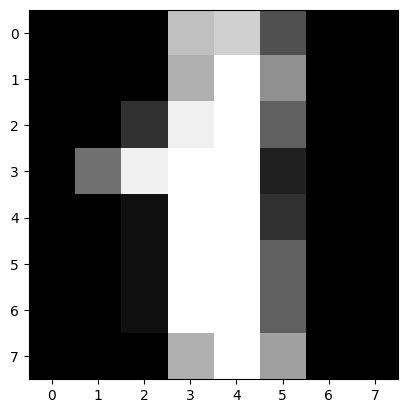

In [25]:
plt.imshow(X[1], cmap='gray', interpolation='nearest');

Try looking at some other digits. Do you see a pattern? Use both the df method and the imshow method

### Discovering the digits

Scikit Learn has AMAZING documentation. One of the best, is its section on [clustering techniques](https://scikit-learn.org/stable/modules/clustering.html). It is useful because **how* we do clustering is usually very similar but **which** technique can be suitable when can be **complex**.

In [26]:
from sklearn.cluster import KMeans
# from sklearn.preprocessing import StandardScaler

In [29]:
kmeans = KMeans(n_clusters=10, random_state=42)
labels = kmeans.fit_predict(X) # the index of the nearest centroid to each value
centeroids = kmeans.cluster_centers_  # the values for the centroid
intertia = kmeans.inertia_ # sum of square distances of each value from its centroid
# you will get an error but see if you can fix it!
# notice the underscore suffix it has a special meaning in a lot of scientific libraries - can you guess what it is?

### What do those mean?

#### Fix for error 

In [28]:
# need to reshape back
X = X.reshape(-1, 64)

#### Counting with our elbow

Let's suppose we knew nothing about digits (how many are there anyway?) and we wanted to use KMeans to figure out how many clusters we should use. One way to do this is to use the "elbow" method. The elbow method is a heuristic used in determining the number of clusters in a data set. The method consists of plotting the explained variation as a function of the number of clusters, and picking the elbow of the curve as the number of clusters to use.

Use the elbow method to determine the optimal number of clusters (notice that you may need to alter the range that you try out)




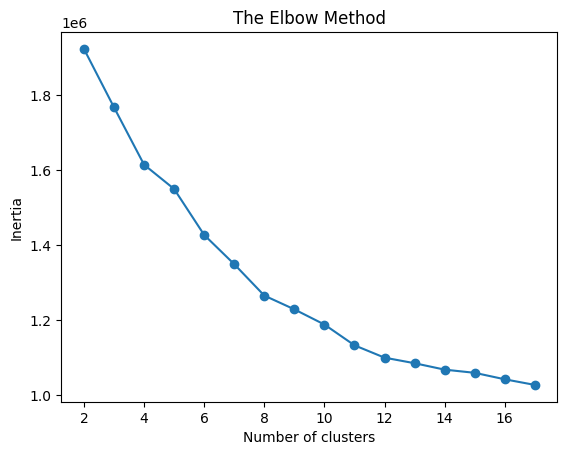

In [30]:
k_range = range(2,18) # try these values of k

inertias = []

for k in k_range:
    # run k-means and get the value of intertias for each k 
    # append to inertias
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
# Add code to plot the optimal number of clusters

plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('The Elbow Method')
plt.show() 

#### Plot the elbow

In [31]:
X

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64))

In [32]:
# scaler = StandardScaler()
# scaler.fit_transform(X)
# X 

Text(0.5, 1.0, 'Elbow Method for Optimal k')

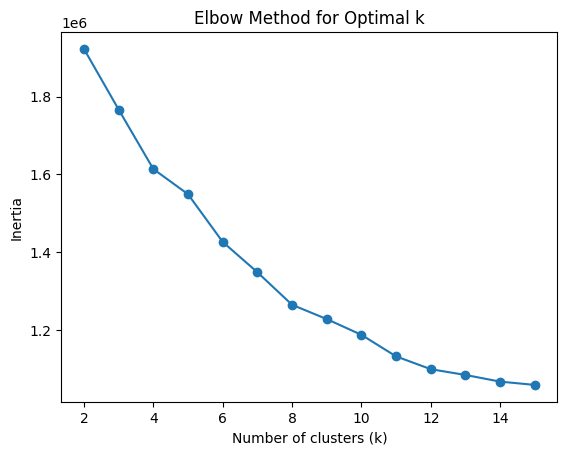

In [34]:
inertias = []
for i in range(2,16):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)


plt.plot(range(2, 16), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')

### Elbow Method: Analysis

Notice that unlike in the synthetic example previously, the elbow method is not perfect. In the case of the digits data set, the elbow is not as clear as it is in other data sets. This is because the digits data set is quite complex and the digits are quite similar to each other. Nevertheless, even if we knew nothing about digits we could start to form an imperfect hypothesis about the number of digits in the data set.

1. What number of clusters would you choose based on the elbow method? Why?
> Answer here
> Based on the elbow method I would choose 8 number of clusters. That is where the "elbow point" is more distinctively represented. This indicates the optimal k, from this point on the improvement slows down. 

2. Was this number the same or different than your intrinsic knowledge of the data set?
> This number was the same compared to the intrinsic knowledge of the data set. Where the 1797 consisted of 64-Dimensional vector and we considered it to be a collection of 8x8 pixle images of handwritted digits. 
>

3. Provide a hypothesis as to why the number of digits and the number of clusters are not obviously the same
> The number of digits and the number of clusters are not the same because the digits can be represented individually, whereas the clusters are grouped based on their similarity of features or their standings on the dataset. They might not all make sense but they represent a grouping. 

4. Should you use your intrinsic knowledge of the data set to determine the number of clusters? Why or why not?
> Intrinsic knowldege of the data set can be used to make initial guesses or hypothesis of certain scenarios/data sets. But it is always good to double check and back up that intuition if one is correct. Especially, to determine the number of clusters within a large dataset, intrinsic knowledge won't be accurate or close to being correct. 
>
>




### Performing the clustering

Try to perform the clustering based on the number of clusters you found. If you are struggling, try to use the code provided in the [Python Data Science Handbook](https://learning.oreilly.com/library/view/python-data-science/9781098121211/ch47.html#ch_0511-k-means_introducing-k-means) 

In [35]:
# insert code here
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

In [36]:
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits.data)
kmeans.cluster_centers_.shape

(10, 64)

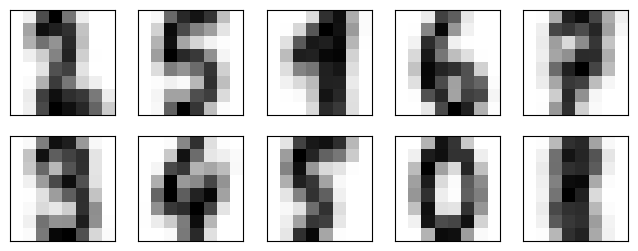

In [37]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

In the above book, there is a section of code that plots the cluster centers. Here it is reproduced below:
    
```python
     fig, ax = plt.subplots(2, 5, figsize=(8, 3))
     centers = kmeans.cluster_centers_.reshape(10, 8, 8)
     for axi, center in zip(ax.flat, centers):
         axi.set(xticks=[], yticks=[])
         axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)
```
[link](https://learning.oreilly.com/library/view/python-data-science/9781098121211/ch47.html#ch_0511-k-means_introducing-k-means)

1. Reproduce this code below and explain what it does:
> Answer here
> The code shows the clusters of a result of 10 clusters in 64 dimensions. 
>

2. Which digit was the most difficult for you to recognize? What does this tell you about that particular digit?

> Answer here
> Number 8 is the hardest to recognize. This image contains a lot more pixels of a darker colour and are grouped / clustered in the same location. 
> 

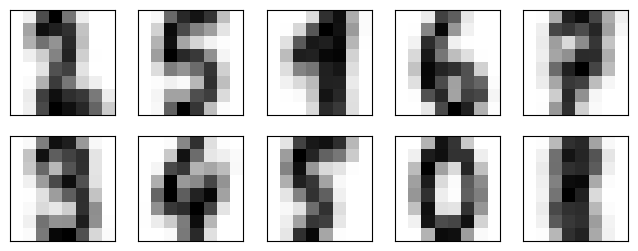

In [94]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
     axi.set(xticks=[], yticks=[])
     axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

## Interpreting the labels

Given what you see in the previous representation, you should be able to have a pretty good guess about how to interpret each cluster. 

Confusingly, when you look at the clusters, they are themselves labelled with  digits.

For example, let's look at the 3rd centroid (i.e. the one that is associated with all points labelled as 2):


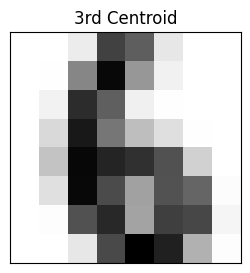

In [38]:
third_centroid = centers[3]
plt.figure(figsize=(3, 3))
plt.imshow(third_centroid, interpolation='nearest', cmap=plt.cm.binary)
plt.xticks([])
plt.yticks([])
plt.title("3rd Centroid")
plt.show()

That is, the points labeled with a `2` should be interpreted as a 6. Obviously it would be nice to assign the true label to these points.

In [39]:
index = 0 # used to set a starting value for the loop. Do not change this line
target_label = 4 # This will search for the first image with a given model assigned to it. Change this value to see other images

In [40]:
# re-run this cell to go to the next value labeled with `2`
j = index + 1
labels = kmeans.labels_
index = next(i for i, label in enumerate(labels[j:], j) if label == target_label)

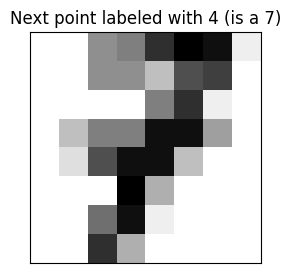

In [50]:
# display value matching the index label above
# run this cell each time after running the cell above
arbitrary_point = digits.data[index].reshape(8, 8)

plt.figure(figsize=(3,3))
plt.imshow(arbitrary_point, interpolation='nearest', cmap=plt.cm.binary)
plt.xticks([])
plt.yticks([])
plt.title(f"Next point labeled with {target_label} (is a {digits.target[index]})")
plt.show()

3. Which digit was labeled with a '4' by our model. Leave the picture of this digit above?
> Answer here
> Digit 7

Remember though that the original `digits` data set is pre-labelled so any time we want we can "cheat" and check how well our model did in identifying the digits (this is the digits.target `np.array`). So while `kmeans.labels_` (notice the underscore) gives us the arbitrary labels that KMeans assigned to the data, we can use the true labels (targets) to assign the correct label to each cluster, automatically. This method will work so long as our clusters were successful enough such that the plurality of the points in each cluster are the same as the target digit.

For example, we can check what the most common 'true' label is for the points in the cluster labelled as 2, and we'll find that it is 6. We can then assign this label to all points in the cluster meaning that when our model assigned 2 to the point, we can say it was identifying a '2' the majority of the time. Hence, we can use the true labels to assign the correct label to each cluster. 

In [51]:
from scipy.stats import mode # statistical function for most frequent value
from sklearn.metrics import accuracy_score

labels = np.zeros_like(kmeans.labels_)
for i in range(10):
    mask = (kmeans.labels_ == i)
    labels[mask] = mode(digits.target[mask])[0]


Now that we have the labels our model assigned to the data corresponding to our interpretation of those labels, coupled with the true labels, we can calculate the accuracy of our model. Above, we imported  the `accuracy_score` function from `sklearn.metrics`. This function takes two arguments: the true labels and the labels assigned by our model. It then returns the accuracy of our model. That is the proportion of points that were correctly assigned to the correct cluster. 

Pretty easy to understand. 

So for example, suppose we had four points that our model identified as a "6" and the true labels were `[6, 6, 6, 2]`. The accuracy would be 0.75 or 75% because three of the four points were identified correctly.

In [52]:
accuracy_score(digits.target, labels)

0.7440178074568725

1. Q. Provide a plain English explanation of the accuracy score you received above:
> Answer here
> The accuracy score received above is 0.74 which is closer to 1, this means that the ratio or correctly predicted instances to the total instances is high. 74% of the time, the classifier made correct predictions when it came to the digits table. 

2. Q. Using the result above, can you determine how accurately the model identifies sixes? Why/why not? 
> Answer here
> Using the result above we can determine how accurately the model identifies 6's. Based on the Acuuracy or the Precision. 
>

3. Q. Related to the above question, what assumption must be true for you to be able to determine how accurately the model identifies a specific digit using just the accuracy score aboev?
> Answer here
> Assuming that the correct digits are grouped as True positives in their respective clusters must be true for us to be able to determine how accurately the model identifies a specific digit using just the accuracy score above. 

4.  Q. Provided that the assumption above is true, can you tell what the chances are of the model identifying a 6 correctly? What about whether it is more likely for the model to misidentify say a 2 for 6 versus  versus misidentifying a 6 for a 2?
> Answer here
> Provided that the assumption that there are more True Positives for each digit, for example 6 being the most grouped number in cluster 6 and so forth. It is more likely for the model to determine a number 2 as a False Positive but still be placed in the same cluster depending on how many of the lables for the target digit is correctly identified before segregation of the clusters begin. 
> But the accuracy score 0.74 suggests that its closer to 1 so there are more TP than TN. 



### Confused? Not Recommended YET!
A confusion matrix is a table that is often used to express the accuracy of a classification model on a set of data where the true labels are known. Unlike the accuracy score, the confusion matrix is able to determine accuracy for specific classifications for any value of `k`. Unlike the accuracy score, it can also distinguish between false positives and false negatives.

Here's how we can produce a confusion matrix for our model:



In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(digits.target, labels)

While this matrix can be used to interpret the accuracy of each classification by our model compared to the true labels, we can present it in a way that can make interpretation much easier (and more visually appealing). We can use the `heatmap` function from the `seaborn` library to do this. The following code will produce a heatmap of the confusion matrix (from the Python Data Science Handbook):


In [ ]:
import seaborn as sns
mat = confusion_matrix(digits.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d',
            cbar=False, cmap='Blues',
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

The diagonal of the matrix represents the true positives (i.e. the number of times the model correctly identified the digit). The off-diagonal elements represent the false positives (i.e. the number of times the model incorrectly identified the digit). 

Using the chart you generated, answer the following questions:

1. Which digit is most likely to be misclassified as a different digit (false negative)? Explain.
> Answer here
> 

2. Which digit(s) is most likely to be classified correctly?
> Answer here
>

3. Q. Which digit is most likely to offer false positives? Explain.
> Answer here
> 

4. If the model classifies a particular value as a 9, what is the probability that it is correct? Include your reasoning/calculations in your answer.
> Answer here
> 

5. Given that the model *incorrectly* classified a particular value as a 9, what is that digit's most likely true value? Include your reasoning/calculations in your answer.
> Answer here
>
> 